# Fuzzy Logic — Final Publication-Ready Models (LOOCV)

**Purpose.** Single, clean implementation of the *winning* leakage-free fuzzy logic
models for the three targets (BMWP, Perlidae, Helicopsychidae), each evaluated under
leave-one-out cross-validation (LOOCV) on the full sample (n = 18).
**Created/modified:** 2026-06-23.
**Supports article section:** Methods (fuzzy redesign) and Results (Table 9).

This notebook consolidates the winners selected in
[`01e_fuzzy_redesign_comparison.ipynb`](01e_fuzzy_redesign_comparison.ipynb):

| Target | Winning approach | Predictors |
|---|---|---|
| BMWP | **E** — Fuzzy C-Means MF + 3 predictors | Conductividad, SDT, Turbiedad |
| Perlidae | **E** — Fuzzy C-Means MF + 3 predictors | Turbiedad, DBO5, SDT |
| Helicopsychidae | **A** — original (expert) MF + 2 predictors | SDT, DBO5 |

## 1. Introduction and methodological context

The original fuzzy notebooks (01a–01c) generated one rule per observation and
evaluated on those same observations. The LOOCV audit in
[`01d`](01d_fuzzy_LOOCV.ipynb) showed this collapses out of sample: **61 % of
held-out stations (11/18) fell into rule combinations no training fold covered**, and
accuracy dropped to chance (BMWP 0.22, Perlidae 0.22, Helicopsychidae 0.11).

The systematic search in `01e` found that the decisive fix is **reducing the
antecedent space** (fewer predictors → far higher rule coverage), optionally combined
with a **leakage-free membership-function estimator** (Fuzzy C-Means fitted inside
each fold). The winners above are reproduced here exactly.

> **Methods-section summary (copy-ready).** Fuzzy inference systems were rebuilt to
> remove the in-sample dependency of the original design. For each target, predictors
> were reduced to the 2–3 strongest (univariate AIC within the five physicochemical
> variables) and the rule base was generated only from the n−1 training observations
> of each leave-one-out fold. Membership functions were either fixed from expert
> criteria (Helicopsychidae) or estimated per fold by Fuzzy C-Means clustering
> (c = 3, m = 2) on the training data alone (BMWP, Perlidae), so that neither the
> rules nor the membership functions used the held-out station. Models were evaluated
> by macro-averaged precision, recall, F1, accuracy and Cohen's κ, plus (for BMWP)
> Spearman's rank correlation between predicted and observed indices over the folds
> that produced an output.

## 2. Data loading (n = 18, no outlier removal)

All 18 observations are retained in the redesigned system. The original
implementation removed 4 observations via IQR-based outlier filtering (n = 14),
creating an asymmetry with other models that used n = 18. Retaining all observations
ensures fair comparison across techniques and maximises available training data
within each LOOCV fold.

In [1]:
# Imports
import numpy as np
import pandas as pd
import functools, operator
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (precision_recall_fscore_support, accuracy_score,
                             cohen_kappa_score, confusion_matrix, classification_report)
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load both datasets in full (no outlier removal)
macro_df = pd.read_excel("../../data/DB - Macroinvertebrados.xlsx")
macro_df.columns = macro_df.columns.str.strip()
bmwp_df = pd.read_excel("../../data/Database - BMWP.xlsx")
bmwp_df.columns = bmwp_df.columns.str.strip()
print("macro:", macro_df.shape, "| bmwp:", bmwp_df.shape)
print("Perlidae +/-:", macro_df['Perlidae'].value_counts().to_dict())
print("Trichoptera (Helicopsychidae) +/-:", macro_df['Trichoptera'].value_counts().to_dict())

macro: (18, 24) | bmwp: (18, 24)
Perlidae +/-: {0: 12, 1: 6}
Trichoptera (Helicopsychidae) +/-: {0: 15, 1: 3}


In [3]:
# ---- Fixed universes and membership-function specifications (identical to 01e) ----
UNIV = {'DBO5': (0,36,0.1), 'OD': (0,10.1,0.1), 'Turbiedad': (0,91,0.1),
        'Conductividad': (0,800,1), 'SDT': (0,800,1)}

ORIG_MF = {
    'DBO5':          [('Bajo','trimf',[0,2,3]), ('Medio','trimf',[2.5,4,6]), ('Alto','trapmf',[5,7,36,36])],
    'OD':            [('Bajo','trapmf',[0,0,5,5.8]), ('Medio','trimf',[5.5,6.3,6.9]), ('Alto','trapmf',[6.5,7,10,10])],
    'Turbiedad':     [('Baja','trimf',[0,2,5]), ('Media','trimf',[4,8,12]), ('Alta','trapmf',[10,20,91,91])],
    'Conductividad': [('Baja','trimf',[50,80,150]), ('Media','trimf',[100,250,400]), ('Alta','trapmf',[300,450,800,800])],
    'SDT':           [('Bajo','trimf',[30,50,70]), ('Medio','trimf',[60,90,110]), ('Alto','trapmf',[100,120,800,800])],
}

BMWP_ORDER = ['Muy critica', 'Critica', 'Dudosa', 'Aceptable', 'Buena']
BMWP_CONS = {'name': 'bmwp', 'universe': (0,121,1), 'terms': [
    ('Muy critica','trimf',[0,0,15]), ('Critica','trimf',[15,35,35]), ('Dudosa','trimf',[36,60,60]),
    ('Aceptable','trimf',[61,100,100]), ('Buena','trimf',[101,120,120])]}
def bin_cons(name):
    return {'name': name, 'universe': (0,1.1,0.1),
            'terms': [('Ausente','trimf',[0,0,0.5]), ('Presente','trimf',[0.5,1,1])]}

def build_fixed(spec, universe):
    u = np.arange(*universe)
    return {lab: getattr(fuzz, kind)(u, par) for lab, kind, par in spec}

def shoulder_terms(universe, peaks):
    """Three value-sorted fuzzy sets with shoulders covering the universe."""
    u = np.arange(*universe)
    umin, umax = float(u[0]), float(u[-1])
    p = sorted(min(max(float(x), umin), umax) for x in peaks)
    eps = (umax - umin) * 1e-3
    if not p[0] < p[1]: p[1] = min(p[0] + eps, umax)
    if not p[1] < p[2]: p[2] = min(p[1] + eps, umax)
    return {'Low': fuzz.trapmf(u, [umin, umin, p[0], p[1]]),
            'Medium': fuzz.trimf(u, [p[0], p[1], p[2]]),
            'High': fuzz.trapmf(u, [p[1], p[2], umax, umax])}

def fcm_terms(train, predictors, c=3, m=2):
    """Fuzzy C-Means on TRAINING predictors only; centroids -> MF peaks per predictor."""
    data = train[predictors].values.T.astype(float)
    cntr, *_ = fuzz.cluster.cmeans(data, c=c, m=m, error=0.005, maxiter=1000, init=None, seed=0)
    return {p: shoulder_terms(UNIV[p], sorted(cntr[:, j])) for j, p in enumerate(predictors)}

def make_fold_mf(mf_type):
    if mf_type == 'orig':
        return lambda train, preds: {p: build_fixed(ORIG_MF[p], UNIV[p]) for p in preds}
    if mf_type == 'fcm':
        return lambda train, preds: fcm_terms(train, preds)
    raise ValueError(mf_type)

def cat_label(value, variable):
    deg = {lab: fuzz.interp_membership(variable.universe, variable[lab].mf, value) for lab in variable.terms}
    return max(deg, key=deg.get)

def run_loocv(df, response, predictors, fold_mf, cons_spec, is_bmwp, threshold=0.5, verbose=False):
    """LOOCV: rules from the n-1 training rows only; held-out row fed its crisp values.
    A fold with no firing rule is recorded as 'No coverage' (counted as incorrect)."""
    loo = LeaveOneOut()
    y_true, y_pred, failed, crisp_ok, num_ok, succ_idx = [], [], [], [], [], []
    n = len(df)
    for fold, (tr, te) in enumerate(loo.split(df)):
        if verbose:
            print(f"{fold+1}", end=' ', flush=True)
        train = df.iloc[tr]; test = df.iloc[te].iloc[0]
        terms = fold_mf(train, predictors)
        antecedents = {}
        for p in predictors:
            a = ctrl.Antecedent(np.arange(*UNIV[p]), p)
            for lab, arr in terms[p].items():
                a[lab] = arr
            antecedents[p] = a
        cons = ctrl.Consequent(np.arange(*cons_spec['universe']), cons_spec['name'])
        for lab, kind, par in cons_spec['terms']:
            cons[lab] = getattr(fuzz, kind)(cons.universe, par)
        rules = []
        for _, row in train.iterrows():
            ante = functools.reduce(operator.and_,
                                    [antecedents[p][cat_label(row[p], antecedents[p])] for p in predictors])
            ct = cons[cat_label(row['BMWP'], cons)] if is_bmwp else (
                cons['Presente'] if row[response] == 1 else cons['Ausente'])
            rules.append(ctrl.Rule(ante, ct))
        sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))
        true_lbl = cat_label(test['BMWP'], cons) if is_bmwp else (
            'Presente' if test[response] == 1 else 'Ausente')
        try:
            for p in predictors:
                sim.input[p] = float(test[p])
            sim.compute()
            out = sim.output[cons_spec['name']]
            pred_lbl = cat_label(out, cons) if is_bmwp else ('Presente' if out >= threshold else 'Ausente')
            y_pred.append(pred_lbl); y_true.append(true_lbl); crisp_ok.append(out); succ_idx.append(fold)
            if is_bmwp:
                num_ok.append(float(test['BMWP']))
        except Exception:
            failed.append(fold); y_pred.append('No coverage'); y_true.append(true_lbl)
    if verbose:
        print("done.")
    return {'y_true': y_true, 'y_pred': y_pred, 'failed': failed,
            'crisp_ok': crisp_ok, 'num_ok': num_ok, 'succ_idx': succ_idx}

def compute_metrics(y_true, y_pred, real_classes):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=real_classes,
                                                 average='macro', zero_division=0)
    try:
        kappa = cohen_kappa_score(y_true, y_pred)
    except Exception:
        kappa = float('nan')
    return {'precision': p, 'recall': r, 'f1': f,
            'accuracy': accuracy_score(y_true, y_pred), 'kappa': kappa}

## 3. Model 1 — BMWP prediction (Approach E: FCM + 3 predictors)

Predictors **Conductividad, SDT, Turbiedad** (top-3 by univariate AIC). In every
fold, Fuzzy C-Means (c = 3, m = 2) is fitted on the training rows only; the three
cluster centroids per predictor become the Low/Medium/High membership-function
peaks. Rules are generated from the training rows and the held-out station is
predicted from its raw crisp values.

In [4]:
# BMWP — Approach E (FCM membership functions, 3 predictors), full LOOCV
bmwp_pred = ['Conductividad', 'SDT', 'Turbiedad']
print("BMWP LOOCV folds:", end=' ')
bmwp_res = run_loocv(bmwp_df, 'BMWP', bmwp_pred, make_fold_mf('fcm'), BMWP_CONS,
                     is_bmwp=True, verbose=True)
bmwp_classes = [cl for cl in BMWP_ORDER if cl in bmwp_res['y_true']]
bmwp_m = compute_metrics(bmwp_res['y_true'], bmwp_res['y_pred'], bmwp_classes)
print(f"Accuracy={bmwp_m['accuracy']:.3f}  Kappa={bmwp_m['kappa']:.3f}  "
      f"Coverage failures={len(bmwp_res['failed'])}/18")

BMWP LOOCV folds: 1 

2 

3 

4 

5 

...

15 

16 

17 

18 

done.
Accuracy=0.556  Kappa=0.345  Coverage failures=1/18


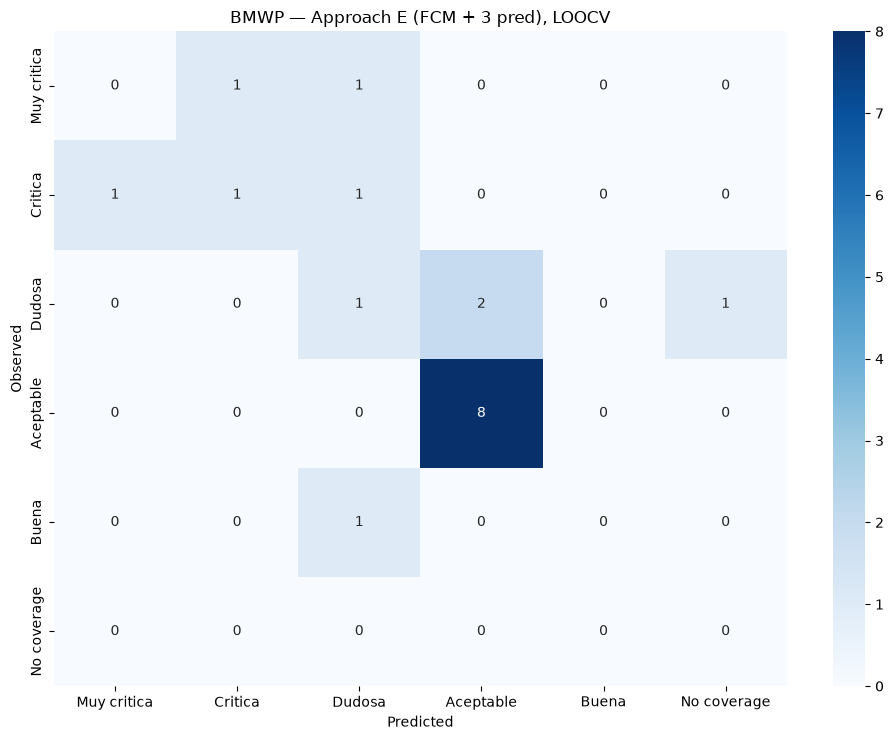

              precision    recall  f1-score   support

 Muy critica       0.00      0.00      0.00         2
     Critica       0.50      0.33      0.40         3
      Dudosa       0.25      0.25      0.25         4
   Aceptable       0.80      1.00      0.89         8
       Buena       0.00      0.00      0.00         1
 No coverage       0.00      0.00      0.00         0

    accuracy                           0.56        18
   macro avg       0.26      0.26      0.26        18
weighted avg       0.49      0.56      0.52        18



In [5]:
# Confusion matrix (BMWP)
labels = bmwp_classes + (['No coverage'] if 'No coverage' in bmwp_res['y_pred'] else [])
cm = confusion_matrix(bmwp_res['y_true'], bmwp_res['y_pred'], labels=labels)
plt.figure(figsize=(1.4*len(labels)+1.5, 1.2*len(bmwp_classes)+1.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('BMWP — Approach E (FCM + 3 pred), LOOCV'); plt.xlabel('Predicted'); plt.ylabel('Observed')
plt.tight_layout(); plt.show()
print(classification_report(bmwp_res['y_true'], bmwp_res['y_pred'], labels=labels, zero_division=0))

In [6]:
# Spearman correlation between predicted crisp BMWP and observed BMWP (successful folds)
bmwp_rs, bmwp_p = spearmanr(bmwp_res['num_ok'], bmwp_res['crisp_ok'])
n_ok = len(bmwp_res['crisp_ok'])
print(f"BMWP LOOCV Spearman r_s = {bmwp_rs:.3f} (p = {bmwp_p:.4g}) over {n_ok} successful folds")

# Persist per-fold predictions for the side-by-side Spearman plot in notebook 05
station_col = 'Estación' if 'Estación' in bmwp_df.columns else bmwp_df.columns[0]
bmwp_loocv_pred = pd.DataFrame({
    'Station': [bmwp_df.iloc[i][station_col] for i in bmwp_res['succ_idx']],
    'Observed_BMWP': bmwp_res['num_ok'],
    'Predicted_BMWP': bmwp_res['crisp_ok'],
})
bmwp_loocv_pred.to_csv("../../outputs/fuzzy_final_bmwp_loocv_predictions.csv", index=False)
print("Saved outputs/fuzzy_final_bmwp_loocv_predictions.csv")

BMWP LOOCV Spearman r_s = 0.533 (p = 0.02745) over 17 successful folds
Saved outputs/fuzzy_final_bmwp_loocv_predictions.csv


## 4. Model 2 — Perlidae habitat suitability (Approach E: FCM + 3 predictors)

Binary presence/absence with predictors **Turbiedad, DBO5, SDT** (top-3 AIC),
Fuzzy C-Means membership functions fitted per fold, threshold 0.5.

In [7]:
# Perlidae — Approach E (FCM, 3 predictors), full LOOCV
perlidae_pred = ['Turbiedad', 'DBO5', 'SDT']
print("Perlidae LOOCV folds:", end=' ')
perl_res = run_loocv(macro_df, 'Perlidae', perlidae_pred, make_fold_mf('fcm'),
                     bin_cons('Perlidae'), is_bmwp=False, verbose=True)
perl_m = compute_metrics(perl_res['y_true'], perl_res['y_pred'], ['Ausente', 'Presente'])
print(f"Accuracy={perl_m['accuracy']:.3f}  Kappa={perl_m['kappa']:.3f}  "
      f"Coverage failures={len(perl_res['failed'])}/18")

Perlidae LOOCV folds: 1 

2 

3 

4 

5 

...

15

16 

17 

18 

done.
Accuracy=0.778  Kappa=0.586  Coverage failures=1/18


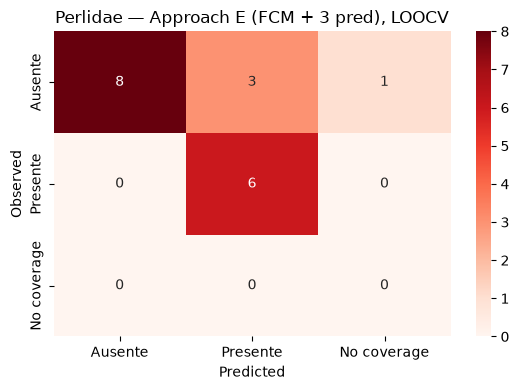

              precision    recall  f1-score   support

     Ausente       1.00      0.67      0.80        12
    Presente       0.67      1.00      0.80         6
 No coverage       0.00      0.00      0.00         0

    accuracy                           0.78        18
   macro avg       0.56      0.56      0.53        18
weighted avg       0.89      0.78      0.80        18



In [8]:
# Confusion matrix (Perlidae)
labels = ['Ausente', 'Presente'] + (['No coverage'] if 'No coverage' in perl_res['y_pred'] else [])
cm = confusion_matrix(perl_res['y_true'], perl_res['y_pred'], labels=labels)
plt.figure(figsize=(1.4*len(labels)+1.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.title('Perlidae — Approach E (FCM + 3 pred), LOOCV'); plt.xlabel('Predicted'); plt.ylabel('Observed')
plt.tight_layout(); plt.show()
print(classification_report(perl_res['y_true'], perl_res['y_pred'], labels=labels, zero_division=0))

## 5. Model 3 — Helicopsychidae habitat suitability (Approach A: original MF + 2 predictors)

Binary presence/absence with predictors **SDT, DBO5** (top-2 AIC) and the original
expert triangular membership functions (fixed, not data-derived). Approach A was the
only low-coverage-failure option with a *positive* Cohen's κ for this rare taxon
(only 3 of 18 stations present); the literature-MF winner by strict priority in 01e
(Approach G) had κ < 0 and merely predicted the majority class.

In [9]:
# Helicopsychidae — Approach A (original MF, 2 predictors), full LOOCV
helico_pred = ['SDT', 'DBO5']
print("Helicopsychidae LOOCV folds:", end=' ')
heli_res = run_loocv(macro_df, 'Trichoptera', helico_pred, make_fold_mf('orig'),
                     bin_cons('Trichoptera'), is_bmwp=False, verbose=True)
heli_m = compute_metrics(heli_res['y_true'], heli_res['y_pred'], ['Ausente', 'Presente'])
print(f"Accuracy={heli_m['accuracy']:.3f}  Kappa={heli_m['kappa']:.3f}  "
      f"Coverage failures={len(heli_res['failed'])}/18")

Helicopsychidae LOOCV folds: 1 

2 

3 

4 

5 

...

15 

16 

17 

18 

done.
Accuracy=0.611  Kappa=0.192  Coverage failures=2/18


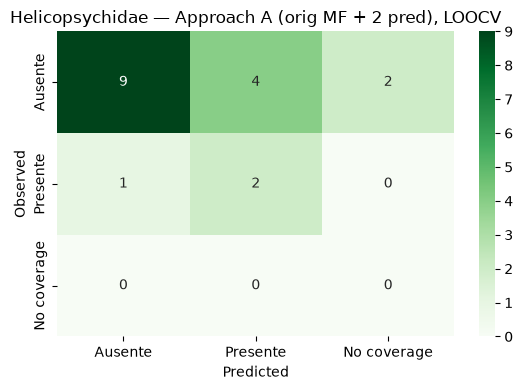

              precision    recall  f1-score   support

     Ausente       0.90      0.60      0.72        15
    Presente       0.33      0.67      0.44         3
 No coverage       0.00      0.00      0.00         0

    accuracy                           0.61        18
   macro avg       0.41      0.42      0.39        18
weighted avg       0.81      0.61      0.67        18



In [10]:
# Confusion matrix (Helicopsychidae)
labels = ['Ausente', 'Presente'] + (['No coverage'] if 'No coverage' in heli_res['y_pred'] else [])
cm = confusion_matrix(heli_res['y_true'], heli_res['y_pred'], labels=labels)
plt.figure(figsize=(1.4*len(labels)+1.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.title('Helicopsychidae — Approach A (orig MF + 2 pred), LOOCV'); plt.xlabel('Predicted'); plt.ylabel('Observed')
plt.tight_layout(); plt.show()
print(classification_report(heli_res['y_true'], heli_res['y_pred'], labels=labels, zero_division=0))

## 6. Final results summary table

Publication-ready fuzzy results (LOOCV, n = 18) with the original in-sample results
(n = 14) shown for contrast. The summary is also written to
`outputs/metrics_fuzzy_redesigned.csv` for the master results notebook.

In [11]:
# Assemble the redesigned-fuzzy summary and the in-sample contrast rows
def r3(x):
    return round(float(x), 3)

redesigned = pd.DataFrame([
    {'Model':'BMWP','Approach':'FCM + 3 pred (E)','n':18,'Predictors':', '.join(bmwp_pred),
     'Precision':r3(bmwp_m['precision']),'Recall':r3(bmwp_m['recall']),'F1':r3(bmwp_m['f1']),
     'Accuracy':r3(bmwp_m['accuracy']),'Kappa':r3(bmwp_m['kappa']),'Failed/18':len(bmwp_res['failed'])},
    {'Model':'Perlidae','Approach':'FCM + 3 pred (E)','n':18,'Predictors':', '.join(perlidae_pred),
     'Precision':r3(perl_m['precision']),'Recall':r3(perl_m['recall']),'F1':r3(perl_m['f1']),
     'Accuracy':r3(perl_m['accuracy']),'Kappa':r3(perl_m['kappa']),'Failed/18':len(perl_res['failed'])},
    {'Model':'Helicopsychidae','Approach':'Orig MF + 2 pred (A)','n':18,'Predictors':', '.join(helico_pred),
     'Precision':r3(heli_m['precision']),'Recall':r3(heli_m['recall']),'F1':r3(heli_m['f1']),
     'Accuracy':r3(heli_m['accuracy']),'Kappa':r3(heli_m['kappa']),'Failed/18':len(heli_res['failed'])},
])

# Original in-sample contrast (from 01d / 01e, n=14)
insample = pd.DataFrame([
    {'Model':'BMWP','Approach':'Original in-sample','n':14,'Predictors':'5 (auto rules)',
     'Precision':0.778,'Recall':0.800,'F1':0.788,'Accuracy':0.929,'Kappa':0.878,'Failed/18':0},
    {'Model':'Perlidae','Approach':'Original in-sample','n':14,'Predictors':'5 (auto rules)',
     'Precision':0.929,'Recall':0.938,'F1':0.928,'Accuracy':0.929,'Kappa':0.857,'Failed/18':0},
    {'Model':'Helicopsychidae','Approach':'Original in-sample','n':14,'Predictors':'5 (auto rules)',
     'Precision':0.875,'Recall':0.955,'F1':0.905,'Accuracy':0.929,'Kappa':0.811,'Failed/18':0},
])
summary = pd.concat([redesigned, insample], ignore_index=True)
display(summary)

,Model,Approach,n,Predictors,Precision,Recall,F1,Accuracy,Kappa,Failed/18
0,BMWP,FCM + 3 pred (E),18,"Conductividad, SDT, Turbiedad",0.310,0.317,0.308,0.556,0.345,1
1,Perlidae,FCM + 3 pred (E),18,"Turbiedad, DBO5, SDT",0.833,0.833,0.800,0.778,0.586,1
2,Helicopsychidae,Orig MF + 2 pred (A),18,"SDT, DBO5",0.617,0.633,0.582,0.611,0.192,2
3,BMWP,Original in-sample,14,5 (auto rules),0.778,0.800,0.788,0.929,0.878,0
4,Perlidae,Original in-sample,14,5 (auto rules),0.929,0.938,0.928,0.929,0.857,0
5,Helicopsychidae,Original in-sample,14,5 (auto rules),0.875,0.955,0.905,0.929,0.811,0


In [12]:
# Export the redesigned metrics in the shared schema used by the master notebook
out = redesigned.rename(columns={'Model':'target'}).copy()
out['technique'] = 'Fuzzy logic (redesigned)'
out['validation'] = 'LOOCV'
out = out.rename(columns={'Precision':'precision','Recall':'recall','F1':'f1',
                          'Accuracy':'accuracy','Kappa':'kappa'})
out = out[['target','technique','validation','n','precision','recall','f1','accuracy','kappa']]
out.to_csv("../../outputs/metrics_fuzzy_redesigned.csv", index=False)

# Also record the BMWP Spearman (in-sample reference + redesigned LOOCV) for notebook 05 / master
pd.DataFrame([
    {'system':'Fuzzy logic (original)','evaluation':'In-sample','n':14,'rs':0.827,'p_value':0.000265},
    {'system':'Fuzzy logic (redesigned)','evaluation':'LOOCV','n':n_ok,'rs':round(bmwp_rs,3),'p_value':bmwp_p},
]).to_csv("../../outputs/spearman_comparison.csv", index=False)
print("Saved outputs/metrics_fuzzy_redesigned.csv and outputs/spearman_comparison.csv")

Saved outputs/metrics_fuzzy_redesigned.csv and outputs/spearman_comparison.csv


## 7. Limitations

- **Membership-function estimation (residual leakage).** This notebook fits Fuzzy
  C-Means **inside each LOOCV fold, on training data only** (BMWP, Perlidae), so the
  membership functions never see the held-out station — this is the leakage-free
  variant from 01e, not a full-dataset FCM. Helicopsychidae uses fixed expert MFs,
  which are likewise independent of the evaluation data. The only design-time
  dependence that remains is **predictor selection by AIC on the full sample**
  (done once, outside the folds); strictly this should be nested inside the CV, so a
  mild optimism remains. The system is therefore *leakage-reduced to the
  membership-function and rule level*, with predictor choice as the residual.
- **Spatial non-independence.** Stations lie along one river; upstream/downstream
  samples share water masses, violating the independence LOOCV assumes. Blocked /
  spatial CV would be stricter but is infeasible at n = 18.
- **Small sample.** With 18 observations (Helicopsychidae: 3 presences; BMWP 'Buena':
  1 station) every metric has wide uncertainty and one fold can move a score.
- **Coverage failures.** A 'No coverage' fold means the held-out station's predictor
  combination matched no training rule — ecologically, a site whose conditions are
  unlike anything in the training set. They are counted as incorrect; the reduced
  antecedent sets keep them rare (0–2/18 here vs 11/18 in the original design).